# Trabajo Práctico Nro. 2
## Machine Learning 2.
### Ejercicio 1.
Alumnos:
  - Crenna, Giuliano.
  - Sancho Almenar, Mariano.
  - Pace, Bruno.

# Configuración del entorno

In [ ]:
!export LD_LIBRARY_PATH=/usr/local/cuda/lib64:$LD_LIBRARY_PATH

In [25]:
# Standard library imports
import os
import pathlib
import urllib.request
import zipfile
import shutil
from pathlib import Path

# Third-party imports
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds
from IPython import display
import librosa

# TensorFlow specific imports
from tensorflow.keras import layers, models, optimizers
from sklearn.metrics import classification_report

# Set the seed value for experiment reproducibility
seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)

In [2]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
        print(e)

2025-06-22 19:44:13.960435: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


# Carga del dataset

Se optó por extraer el datase desde el repositorio de github. Este contiene 3000 audios en lugar de 2500. Se cambió el uso del load directo de tensorflow-datasets.

In [33]:
DATASET_URL: str = "https://github.com/Jakobovski/free-spoken-digit-dataset/archive/refs/heads/master.zip"
DATASET_PATH: str = 'data/spoken_digits'
RAW_DATA_PATH: str = os.path.join(DATASET_PATH, 'recordings')
ZIP_FILE: str = 'spoken_digits.zip'

data_dir = pathlib.Path(DATASET_PATH)
data_dir.mkdir(parents=True, exist_ok=True)

if not os.path.exists(RAW_DATA_PATH):
    print("Downloading the Spoken Digit dataset...")
    urllib.request.urlretrieve(DATASET_URL, ZIP_FILE)

    with zipfile.ZipFile(ZIP_FILE, 'r') as zip_ref:
        zip_ref.extractall(DATASET_PATH)

    extracted_folder = os.path.join(DATASET_PATH, 'free-spoken-digit-dataset-master', 'recordings')
    shutil.move(extracted_folder, DATASET_PATH)

    os.remove(ZIP_FILE)
    shutil.rmtree(os.path.join(DATASET_PATH, 'free-spoken-digit-dataset-master'))
    print("Descarga y extracción completa")
else:
    print("El dataset ya existe.")

El dataset ya existe.


In [4]:
def organize_fsdd_dataset(raw_data_path: str, organized_data_path: str) -> None:
    """Reordena los FSDD en carpetas de clase."""

    Path(organized_data_path).mkdir(parents=True, exist_ok=True)

    for digit in range(10):
        os.makedirs(os.path.join(organized_data_path, str(digit)), exist_ok=True)

    for file_path in Path(raw_data_path).glob('*.wav'):
        digit = file_path.name.split('_')[0]  
        dest_path = os.path.join(organized_data_path, digit, file_path.name)
        shutil.move(str(file_path), dest_path)

    print(f"Dataset reorganizado en: {organized_data_path}")

RAW_DATA_PATH: str = 'data/spoken_digits/recordings'  
ORGANIZED_DATA_PATH: str = 'data/spoken_digits_organized'

organize_fsdd_dataset(RAW_DATA_PATH, ORGANIZED_DATA_PATH)

Dataset reorganizado en: data/spoken_digits_organized


Obtenemos datos de los audios para tomar decisiones posteriores. Nos interesa hacer una especie de normalización.

In [5]:
def analyze_sequence_lengths(data_path: str) -> dict[str, int]:
    """Analiza audios en samples y devuelve un diccionario con las estadísticas"""
    sequence_lengths = []

    # Find all WAV files recursively in class subdirectories
    wav_files = list(Path(data_path).rglob('*.wav'))

    if not wav_files:
        raise ValueError(f"No WAV files found in {data_path}")

    for file_path in wav_files:
        try:
            audio, _ = librosa.load(file_path, sr=None)  # Keep original sample rate
            sequence_lengths.append(len(audio))
        except Exception as e:
            print(f"Skipping {file_path.name}: {str(e)}")
            continue

    if not sequence_lengths:
        raise ValueError("No valid audio files processed")

    stats = {
        'min_samples': int(np.min(sequence_lengths)),
        'max_samples': int(np.max(sequence_lengths)),
        'mean_samples': int(np.mean(sequence_lengths)),
        'median_samples': int(np.median(sequence_lengths)),
        '95th_percentile': int(np.percentile(sequence_lengths, 95)),
        'total_files': len(sequence_lengths)
    }

    print("\nAudio Sequence Length (Samples)")
    print("-----------------------------")
    print(f"• Minimum: {stats['min_samples']:,} samples")
    print(f"• Maximum: {stats['max_samples']:,} samples")
    print(f"• Mean: {stats['mean_samples']:,} samples")
    print(f"• Median: {stats['median_samples']:,} samples")
    print(f"• 95th Percentile: {stats['95th_percentile']:,} samples")
    print(f"\nTotal files analyzed: {stats['total_files']}")
    return stats


stats = analyze_sequence_lengths('data/spoken_digits_organized')

stats['median_samples']


Audio Sequence Length (Samples)
-----------------------------
• Minimum: 1,148 samples
• Maximum: 18,262 samples
• Mean: 3,499 samples
• Median: 3,358 samples
• 95th Percentile: 5,299 samples

Total files analyzed: 3000


3358

# Preparación del dataset para las redes neuronales y EDA

Se crea el dataset teniendo en cuenta que la longitud de los audios es la media (promedio) del dataset.

In [7]:
# Parameters
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2
SEED = 42
SEQUENCE_LENGTH = stats['median_samples']

# Create datasets
train_ds, val_ds = tf.keras.utils.audio_dataset_from_directory(
    directory=ORGANIZED_DATA_PATH,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    seed=SEED,
    output_sequence_length=SEQUENCE_LENGTH,
    subset='both',
    #labels='inferred',
    #label_mode='categorical'
)

# Get class names
label_names = np.array(train_ds.class_names)
print("\nLabel names:", label_names)

# Preview the dataset
print("\nDataset structure:")
for audio_batch, label_batch in train_ds.take(1):
    print("Audio batch shape:", audio_batch.shape)
    print("Label batch shape:", label_batch.shape)
    print("First label:", label_batch[0].numpy())

Found 3000 files belonging to 10 classes.
Using 2400 files for training.
Using 600 files for validation.

Label names: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']

Dataset structure:
Audio batch shape: (32, 3358, 1)
Label batch shape: (32,)
First label: 4


2025-06-22 19:45:35.506526: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [9]:
def squeeze(audio, labels):
  audio = tf.squeeze(audio, axis=-1)
  return audio, labels

train_ds = train_ds.map(squeeze, tf.data.AUTOTUNE)
val_ds = val_ds.map(squeeze, tf.data.AUTOTUNE)

In [10]:
for example_audio, example_labels in train_ds.take(1):
  print(example_audio.shape)
  print(example_labels.shape)

(32, 3358)
(32,)


Podemos observar que no todos los números tienen el mismo patrón en la onda del sonido.

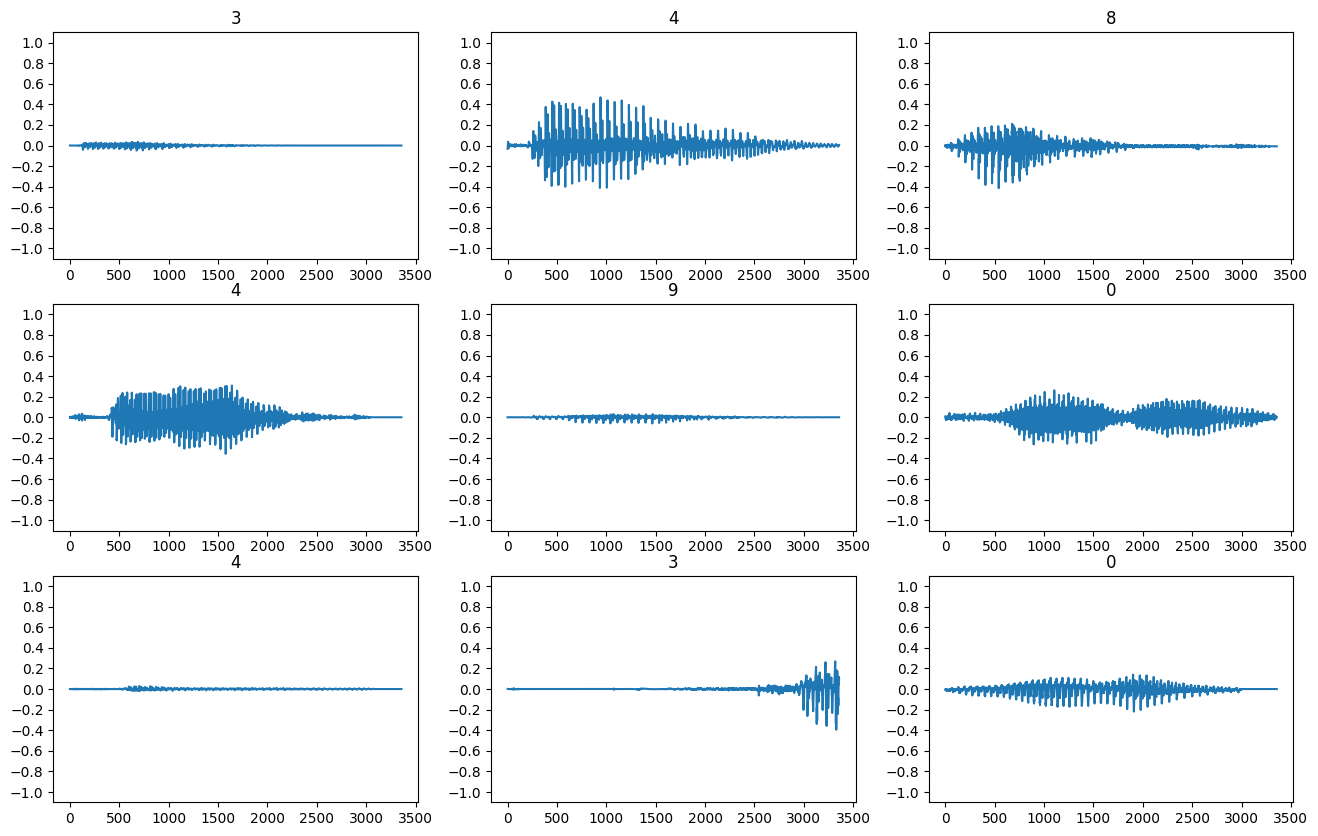

In [11]:
plt.figure(figsize=(16, 10))
rows = 3
cols = 3
n = rows * cols
for i in range(n):
  plt.subplot(rows, cols, i+1)
  audio_signal = example_audio[i]
  plt.plot(audio_signal)
  plt.title(label_names[example_labels[i]])
  plt.yticks(np.arange(-1.2, 1.2, 0.2))
  plt.ylim([-1.1, 1.1])

In [12]:
def get_spectrogram(waveform):
  # Convert the waveform to a spectrogram via a STFT.
  spectrogram = tf.signal.stft(
      waveform, frame_length=255, frame_step=128)
  # Obtain the magnitude of the STFT.
  spectrogram = tf.abs(spectrogram)
  # Add a `channels` dimension, so that the spectrogram can be used
  # as image-like input data with convolution layers (which expect
  # shape (`batch_size`, `height`, `width`, `channels`).
  spectrogram = spectrogram[..., tf.newaxis]
  return spectrogram

Extraemos tres audios para escucharlos.

In [13]:
for i in range(3):
  label = label_names[example_labels[i]]
  waveform = example_audio[i]
  spectrogram = get_spectrogram(waveform)

  print('Label:', label)
  print('Waveform shape:', waveform.shape)
  print('Spectrogram shape:', spectrogram.shape)
  print('Audio playback')
  display.display(display.Audio(waveform, rate=16000))

Label: 3
Waveform shape: (3358,)
Spectrogram shape: (25, 129, 1)
Audio playback


Label: 4
Waveform shape: (3358,)
Spectrogram shape: (25, 129, 1)
Audio playback


Label: 8
Waveform shape: (3358,)
Spectrogram shape: (25, 129, 1)
Audio playback


In [14]:
def plot_spectrogram(spectrogram, ax):
  if len(spectrogram.shape) > 2:
    assert len(spectrogram.shape) == 3
    spectrogram = np.squeeze(spectrogram, axis=-1)
  # Convert the frequencies to log scale and transpose, so that the time is
  # represented on the x-axis (columns).
  # Add an epsilon to avoid taking a log of zero.
  log_spec = np.log(spectrogram.T + np.finfo(float).eps)
  height = log_spec.shape[0]
  width = log_spec.shape[1]
  X = np.linspace(0, np.size(spectrogram), num=width, dtype=int)
  Y = range(height)
  ax.pcolormesh(X, Y, log_spec)

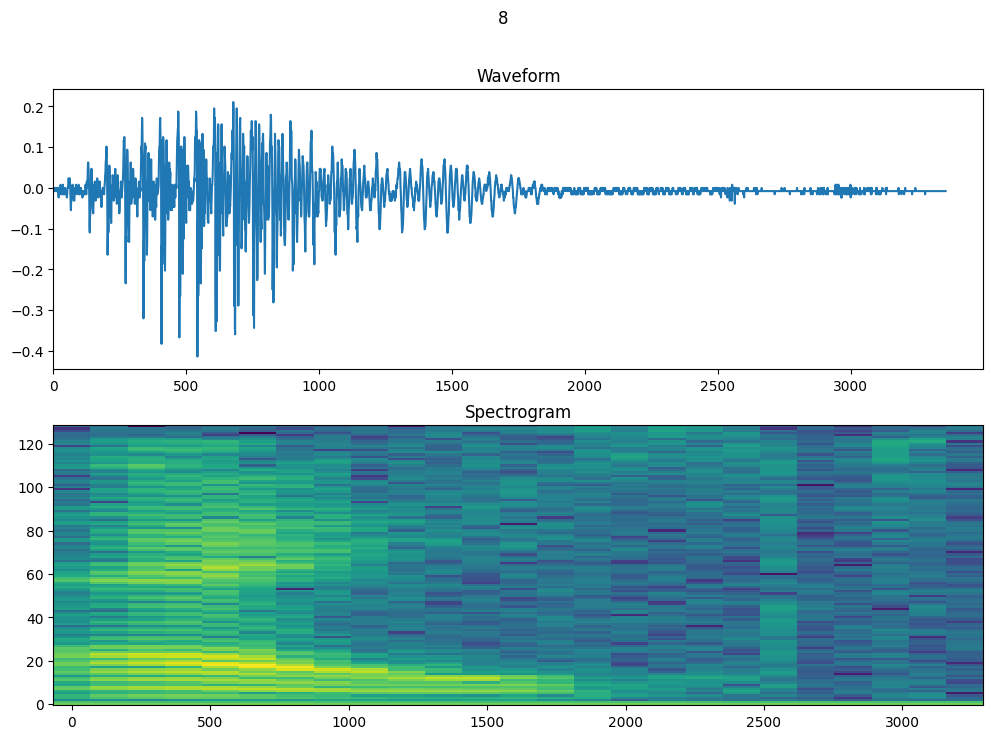

In [15]:
fig, axes = plt.subplots(2, figsize=(12, 8))
timescale = np.arange(waveform.shape[0])
axes[0].plot(timescale, waveform.numpy())
axes[0].set_title('Waveform')
axes[0].set_xlim([0, stats['mean_samples']])

plot_spectrogram(spectrogram.numpy(), axes[1])
axes[1].set_title('Spectrogram')
plt.suptitle(label.title())
plt.show()

In [16]:
def make_spec_ds(ds):
  return ds.map(
      map_func=lambda audio,label: (get_spectrogram(audio), label),
      num_parallel_calls=tf.data.AUTOTUNE)

In [17]:
train_spectrogram_ds = make_spec_ds(train_ds)
val_spectrogram_ds = make_spec_ds(val_ds)

In [18]:
for example_spectrograms, example_spect_labels in train_spectrogram_ds.take(1):
  break

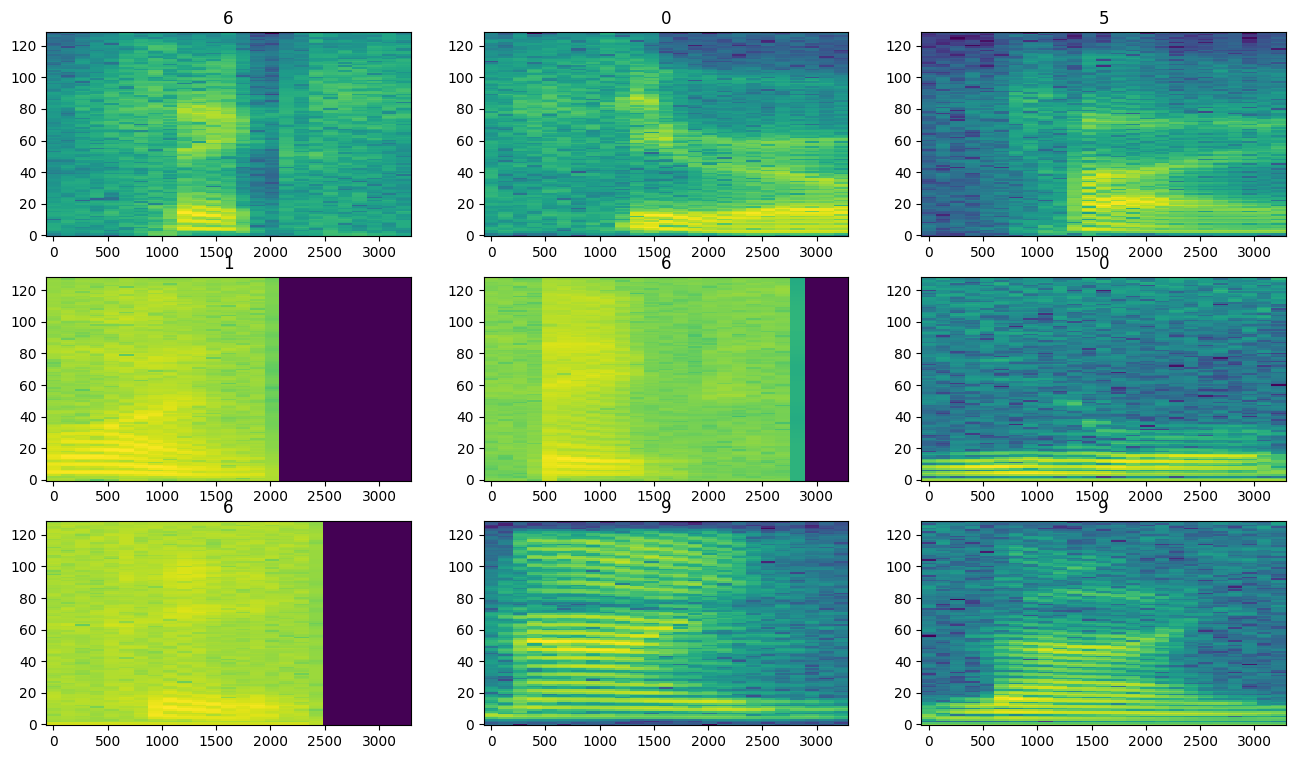

In [19]:
rows = 3
cols = 3
n = rows*cols
fig, axes = plt.subplots(rows, cols, figsize=(16, 9))

for i in range(n):
    r = i // cols
    c = i % cols
    ax = axes[r][c]
    plot_spectrogram(example_spectrograms[i].numpy(), ax)
    ax.set_title(label_names[example_spect_labels[i].numpy()])

plt.show()

Visualizamos que cada numero ostenta un patrón distinto. También podemos remarcar que hay audios que tienen padding.

# CNN

Para implementar la red convolucional, se reforma el dataset a imagenes de espectogramas.

In [20]:
train_spectrogram_ds = train_spectrogram_ds.cache().shuffle(10000).prefetch(tf.data.AUTOTUNE)
val_spectrogram_ds = val_spectrogram_ds.cache().prefetch(tf.data.AUTOTUNE)

Creación de la red neuronal.

In [21]:
input_shape = example_spectrograms.shape[1:]
print('Input shape:', input_shape)
num_labels = len(label_names)

# Instantiate the `tf.keras.layers.Normalization` layer.
norm_layer = layers.Normalization()
# Fit the state of the layer to the spectrograms
# with `Normalization.adapt`.
norm_layer.adapt(data=train_spectrogram_ds.map(map_func=lambda spec, label: spec))

model = models.Sequential([
    layers.Input(shape=input_shape),
    # Downsample the input.
    layers.Resizing(32, 32),
    # Normalize.
    norm_layer,
    layers.Conv2D(32, 3, activation='relu'),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_labels),
])

model.summary()

Input shape: (25, 129, 1)


2025-06-22 19:46:51.801559: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization (Normalization)   │ (None, 32, 32, 1)      │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,625,869 (6.20 MB)

 Trainable params: 1,625,866 (6.20 MB)

 Non-trainable params: 3 (16.00 B)

In [22]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'],
)

In [23]:
EPOCHS = 50

history = model.fit(
    train_spectrogram_ds,
    validation_data=val_spectrogram_ds,
    epochs=EPOCHS,
    callbacks=tf.keras.callbacks.EarlyStopping(verbose=1, patience=5),
)

Epoch 1/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 16s 185ms/step - accuracy: 0.3005 - loss: 1.9908 - val_accuracy: 0.6883 - val_loss: 1.0050
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 14s 188ms/step - accuracy: 0.6354 - loss: 1.1051 - val_accuracy: 0.8267 - val_loss: 0.6035
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 19s 165ms/step - accuracy: 0.7653 - loss: 0.6888 - val_accuracy: 0.8633 - val_loss: 0.4556
Epoch 4/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 13s 170ms/step - accuracy: 0.8457 - loss: 0.5314 - val_accuracy: 0.9150 - val_loss: 0.3107
Epoch 5/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 14s 180ms/step - accuracy: 0.8829 - loss: 0.3698 - val_accuracy: 0.9383 - val_loss: 0.2173
Epoch 6/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 14s 182ms/step - accuracy: 0.9043 - loss: 0.3006 - val_accuracy: 0.9383 - val_loss: 0.1936
Epoch 7/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 12s 159ms/step - accuracy: 0.9131 - loss: 0.2569 - val_accuracy: 0.9417 - val_loss: 0.1976
Epoch 8/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 14s 182ms/step - accuracy: 0.9236 - loss: 0.2344 - val_accu

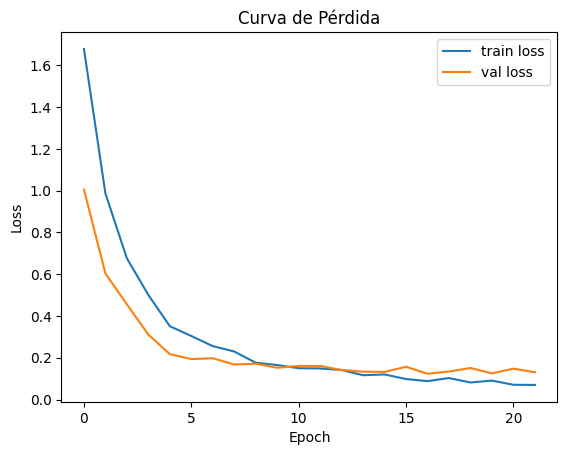

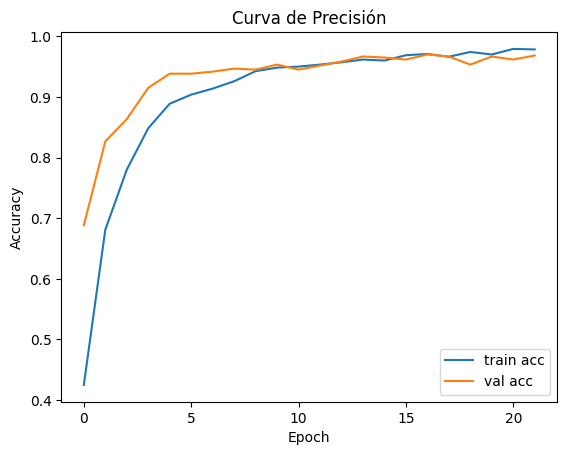

In [31]:
plt.figure()
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Curva de Pérdida')
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Curva de Precisión')
plt.legend()
plt.show()

final_train_loss = history.history['loss'][-1]
final_val_loss   = history.history['val_loss'][-1]
final_train_acc  = history.history['accuracy'][-1]
final_val_acc    = history.history['val_accuracy'][-1]

In [54]:
print(f"Final Train → Loss: {final_train_loss:.4f}   Accuracy: {final_train_acc:.4f}")
print(f"Final Val   → Loss: {final_val_loss:.4f}   Accuracy: {final_val_acc:.4f}")

Final Train → Loss: 0.0675   Accuracy: 0.9771
Final Val   → Loss: 0.1499   Accuracy: 0.9550


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


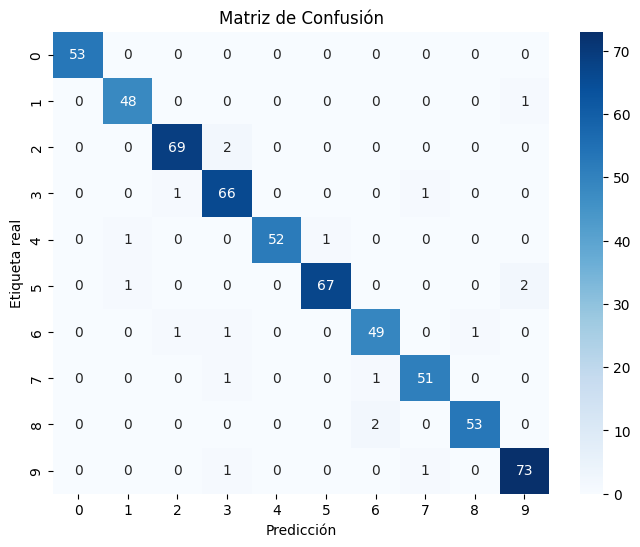


-------------------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       0.96      0.98      0.97        49
           2       0.97      0.97      0.97        71
           3       0.93      0.97      0.95        68
           4       1.00      0.96      0.98        54
           5       0.99      0.96      0.97        70
           6       0.94      0.94      0.94        52
           7       0.96      0.96      0.96        53
           8       0.98      0.96      0.97        55
           9       0.96      0.97      0.97        75

    accuracy                           0.97       600
   macro avg       0.97      0.97      0.97       600
weighted avg       0.97      0.97      0.97       600

-------------------------------------------


In [29]:
# Obtener las verdaderas etiquetas y las predicciones del modelo
y_true = []
y_pred = []

for audio_batch, label_batch in val_spectrogram_ds:
    # Predicciones del modelo (logits o probabilidades)
    predictions = model.predict(audio_batch)
    
    # Convertir a índice de clase si es one-hot o logits
    predicted_labels = np.argmax(predictions, axis=1)
    true_labels = label_batch.numpy()  # asumiendo que las etiquetas no están one-hot

    y_pred.extend(predicted_labels)
    y_true.extend(true_labels)

# Convertir a arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

def show_confusion_matrix(y_pred: np.ndarray, y_true: np.ndarray, class_names: list[str]) -> None:
    """
    Grafica la matriz de confusión y muestra el classification report.

    Args:
        y_pred (np.ndarray): Predicciones del modelo (índices de clase)
        y_true (np.ndarray): Etiquetas reales (índices de clase)
        class_names (list): Lista de nombres de clases
    """
    # Calcular la matriz de confusión
    confusion_mtx = tf.math.confusion_matrix(y_true, y_pred).numpy()

    # Graficar
    plt.figure(figsize=(8, 6))
    plt.title("Matriz de Confusión")
    sns.heatmap(confusion_mtx, xticklabels=class_names, yticklabels=class_names,
                annot=True, fmt='g', cmap="Blues")
    plt.xlabel('Predicción')
    plt.ylabel('Etiqueta real')
    plt.show()

    # Mostrar classification report
    print("\n-------------------------------------------")
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    print("-------------------------------------------")


show_confusion_matrix(y_pred, y_true, label_names)

Podemos ver que las métricas en todos los casos son excelentes. Aquí podemos apreciar que diferencia las clases casi de forma perfecta. Tanto F1 como Recall ilustran esto.

In [32]:
model.save('models/cnn.keras')

# LSTM

In [56]:
BATCH_SIZE = 32
EPOCHS = 100
SR = 16000
N_MEL_BINS = 64
FRAME_LENGTH = 256
FRAME_STEP = 128
EPS = 1e-6

def create_lstm(input_shape, num_labels):
    """
    Crea un modelo LSTM bidireccional para clasificación de secuencias MFCC.

    Parámetros
    ----------
    input_shape : tuple de int
        Forma de la entrada por ejemplo (timesteps, 13), que coincide con
        la salida de waveform_to_mfcc para cada muestra.
    num_labels : int
        Número de clases de salida (tamaño del vocabulario de etiquetas).

    Devuelve
    -------
    model : tf.keras.Model
        Modelo compilado listo para entrenar con loss
        'sparse_categorical_crossentropy' y métrica 'accuracy'.
    """
    
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        layers.Bidirectional(layers.LSTM(64)),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),

        layers.Dense(num_labels, activation='softmax')
    ])
    
    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-4, clipnorm=1.0),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

def waveform_to_mfcc(waveform, label):
    """
    Convierte lotes de forma de onda en su representación MFCC normalizada.

    Parámetros
    ----------
    waveform : tf.Tensor
        Tensor de tipo float32 con forma [batch_size, seq_length, 1],
        donde `seq_length` == output_sequence_length definido en
        audio_dataset_from_directory. Cada valor está en [-1.0, +1.0].
    label : tf.Tensor
        Tensor de enteros con forma [batch_size], la etiqueta
        de clase para cada ejemplo de audio.

    Devuelve
    -------
    mfccs : tf.Tensor
        Tensor float32 con forma [batch_size, timesteps, 13], donde
        `timesteps = 1 + (seq_length - FRAME_LENGTH) // FRAME_STEP`.
        Son los 13 primeros coeficientes MFCC, normalizados en
        media 0 y desviación estándar 1 a lo largo del eje temporal.
    label : tf.Tensor
        Mismas etiquetas de entrada, sin modificar.
    """
    waveform = tf.squeeze(waveform, axis=-1)

    # STFT → espectrograma
    spec = tf.signal.stft(
        waveform,
        frame_length=FRAME_LENGTH,
        frame_step=FRAME_STEP
    )
    spec = tf.abs(spec) 

    mel_matrix = tf.signal.linear_to_mel_weight_matrix(
        num_mel_bins=N_MEL_BINS,
        num_spectrogram_bins=spec.shape[-1],
        sample_rate=SR
    )
    mel_spec = tf.tensordot(spec, mel_matrix, axes=1)  

    log_mel = tf.math.log(mel_spec + EPS)
    mfccs = tf.signal.mfccs_from_log_mel_spectrograms(log_mel)[..., :13] 

    # Normalizar cada coeficiente a lo largo del eje temporal
    mean = tf.reduce_mean(mfccs, axis=1, keepdims=True)
    std  = tf.math.reduce_std(mfccs, axis=1, keepdims=True)
    mfccs = (mfccs - mean) / (std + EPS)

    return mfccs, label


In [ ]:
train_ds, val_ds = tf.keras.utils.audio_dataset_from_directory(
    directory=ORGANIZED_DATA_PATH,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    seed=SEED,
    output_sequence_length=SEQUENCE_LENGTH,
    subset='both',
)

train_ds = (
    train_ds
    .map(waveform_to_mfcc, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .shuffle(1000)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    val_ds
    .map(waveform_to_mfcc, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)


for x_batch, y_batch in train_ds.take(1):
    input_shape = x_batch.shape[1:]
    num_labels = int(tf.reduce_max(y_batch).numpy()) + 1
    break

model = create_lstm(input_shape, num_labels)
model.summary()

Found 3000 files belonging to 10 classes.
Using 2400 files for training.
Using 600 files for validation.


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_8 (Bidirectional) │ (None, 25, 128)        │        39,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 25, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 25, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_9 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 148,938 (581.79 KB)

 Trainable params: 148,298 (579.29 KB)

 Non-trainable params: 640 (2.50 KB)

In [58]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.1261 - loss: 3.2874 - val_accuracy: 0.2117 - val_loss: 2.2355
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.1911 - loss: 2.8784 - val_accuracy: 0.3017 - val_loss: 2.0582
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.2471 - loss: 2.4700 - val_accuracy: 0.4550 - val_loss: 1.7319
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.2978 - loss: 2.2023 - val_accuracy: 0.5683 - val_loss: 1.4064
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.3385 - loss: 2.0663 - val_accuracy: 0.6217 - val_loss: 1.1531
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.4124 - loss: 1.8223 - val_accuracy: 0.6617 - val_loss: 0.9946
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.4576 - loss: 1.6982 - val_accuracy: 0.6883 - val_loss: 0.8892
Epoch 8/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.4756 - loss: 1.5666 - val_accuracy: 0.

In [ ]:
model.save("models/lstm.keras")

In [60]:
train_loss, train_acc = model.evaluate(
    train_ds,
    verbose=1
)
print(f"Train -> Loss: {train_loss:.4f}   Accuracy: {train_acc:.4f}")

val_loss, val_acc = model.evaluate(
    val_ds,
    verbose=1
)
print(f"Val. -> Loss: {val_loss:.4f}   Accuracy: {val_acc:.4f}")

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9984 - loss: 0.0075
Train -> Loss: 0.0079   Accuracy: 0.9979
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9625 - loss: 0.1619
Val. -> Loss: 0.1308   Accuracy: 0.9683


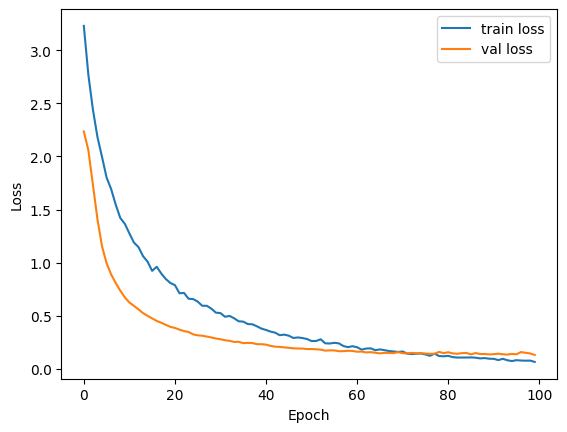

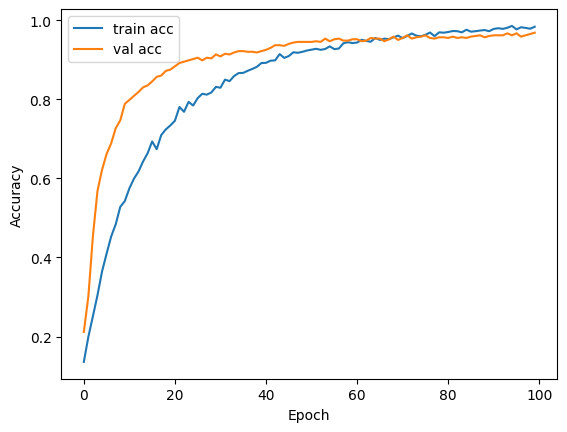

In [61]:
plt.figure()
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Informe y Análisis de Resultados

## 1. Descripción de los experimentos

Se compararon dos arquitecturas para la clasificación de audio:

* **CNN** (red convolucional sobre espectrogramas)  
* **RNN** (LSTM bidireccional sobre secuencias de MFCC)

Para cada modelo se entrenó durante un máximo de 100 épocas (con EarlyStopping de paciencia 5 en la CNN), evaluando en cada época la pérdida (`loss`) y la precisión (`accuracy`) en los conjuntos de entrenamiento y validación.

---

## 2. Curvas de pérdida

### 2.1. CNN

![Pérdida CNN](https://raw.githubusercontent.com/bpace1/ML-RNN-RL/main/ej_1/output/perdida_cnn.png)

* **Descenso rápido** durante las primeras 5–6 épocas.  
* **Estabilización** de la pérdida de validación en torno a 0.10–0.12 tras aplicar EarlyStopping (~época 20).  
* **Breves repuntes** de `val_loss` que sugieren algo de variabilidad, pero sin una tendencia clara de sobreajuste prematuro.

### 2.2. RNN

![Pérdida RNN](https://raw.githubusercontent.com/bpace1/ML-RNN-RL/main/ej_1/output/perdida_rnn.png)

* **Descenso más gradual** en comparación con la CNN, extendiéndose hasta cerca de la época 80.  
* La **pérdida de entrenamiento** baja más lentamente, indicando que la RNN requiere más épocas para ajustarse.  
* La **pérdida de validación** se estabiliza cerca de 0.12–0.14 alrededor de la época 80–90.

---

## 3. Curvas de precisión

### 3.1. CNN

![Precisión CNN](https://raw.githubusercontent.com/bpace1/ML-RNN-RL/main/ej_1/output/presicion_cnn.png)

* **Arranque rápido**: `val_accuracy` supera 0.85 en la época 3.  
* **Rápida convergencia** hacia 0.92–0.94 en las épocas 5–8.  
* **Mejora marginal** posterior, alcanzando pico de ~0.96 hacia la época 15–20 antes de detenerse.

### 3.2. RNN

![Precisión RNN](https://raw.githubusercontent.com/bpace1/ML-RNN-RL/main/ej_1/output/presicion_rnn.png)

* **Inicialmente baja** (~0.15) pero incrementa de forma continua.  
* **Se cruza con la CNN** alrededor de la época 30, cuando `train_accuracy` y `val_accuracy` superan 0.90.  
* **Convergencia lenta** hacia 0.98–0.99 a partir de la época 80, demostrando un potencial de precisión ligeramente superior al final.

---

## 4. Comparativa y conclusiones

| Métrica                     | CNN                    | RNN                       |
| --------------------------- | ---------------------- | ------------------------- |
| **Rápidez de convergencia** | Muy alta (5–8 épocas)  | Media–baja (30–80 épocas) |
| **Loss mínimo validación**  | ~0.10–0.12 (época 20)  | ~0.12–0.14 (época 80)     |
| **Accuracy validación**     | ~0.96 (época 15–20)    | ~0.99 (época 90–100)      |
| **Estabilidad**             | Pequeños repuntes      | Curvas suaves             |

1. **CNN**  
   * Ideal si se busca **rápida iteración** y menor tiempo de entrenamiento.  
   * Buen trade-off entre velocidad y precisión (~96 %).  
   * Menos sensible a overfitting gracias al EarlyStopping.

2. **RNN**  
   * Requiere **muchas más épocas** pero acaba logrando **ligeramente mayor precisión** (~99 %).  
   * Más estable en sus curvas de validación, sin repuntes bruscos.  
   * Útil si se dispone de mayor tiempo de cómputo y se quiere exprimir al máximo el performance.  

## Nota:
### ¿Por que usamos una frecuencia de muestreo de 16 kHz?

- **Cobertura del espectro de la voz humana**  
  La voz humana contiene información relevante principalmente entre 80 Hz y 8 kHz. Según el teorema de Nyquist, una frecuencia de muestreo de 16 kHz permite reconstruir correctamente todo el contenido hasta 8 kHz sin aliasing.

- **Balance calidad / tamaño**  
  Aumentar la frecuencia de muestreo por encima de 16 kHz (por ejemplo a 44,1 kHz) ofrece muy poca ganancia en calidad para tareas de reconocimiento de dígitos y multiplica innecesariamente el tamaño de los datos y el tiempo de entrenamiento.

- **Eficiencia computacional**  
  Al usar 16 kHz reducimos el número de muestras procesadas por segundo, lo que acelera la extracción de características (MFCC, espectrogramas) y el entrenamiento de la red sin sacrificar el rendimiento en la clasificación de dígitos.
